In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("amazonreviews.tsv", sep="\t")

In [3]:
df.head()


,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


In [4]:
df.shape

(10000, 2)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


In [6]:
df.isnull().sum()

label     0
review    0
dtype: int64

In [7]:
 df.duplicated().sum()

np.int64(0)

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.dropna(inplace=True)

In [10]:
df.reset_index(drop=True, inplace=True)

label
neg    5097
pos    4903
Name: count, dtype: int64


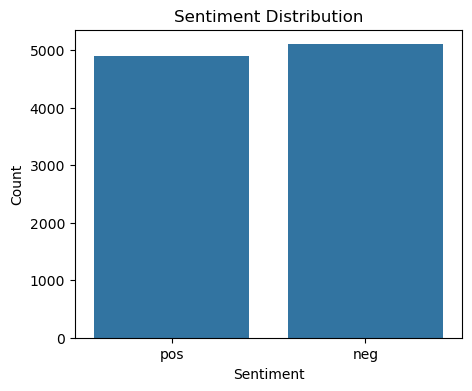

In [11]:
# Count of each sentiment
print(df['label'].value_counts())

# Plot sentiment distribution
plt.figure(figsize=(5,4))
sns.countplot(x='label', data=df)
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [12]:

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

## Text Preprocessing

#### The following steps are done:
#### Convert text to lowercase
#### Remove special characters and numbers
#### Remove common words (stopwords)
#### Convert words to their basic form using lemmatization


In [13]:
# Initialize
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Text preprocessing function
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    
    # Remove special characters and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Tokenize
    words = text.split()
    
    # Remove stopwords and lemmatize
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    
    return " ".join(words)

In [14]:
df['clean_review'] = df['review'].apply(preprocess_text)


df[['review', 'clean_review']].head()

,review,clean_review
0,Stuning even for the non-gamer: This sound tra...,stuning even nongamer sound track beautiful pa...
1,The best soundtrack ever to anything.: I'm rea...,best soundtrack ever anything im reading lot r...
2,Amazing!: This soundtrack is my favorite music...,amazing soundtrack favorite music time hand in...
3,Excellent Soundtrack: I truly like this soundt...,excellent soundtrack truly like soundtrack enj...
4,"Remember, Pull Your Jaw Off The Floor After He...",remember pull jaw floor hearing youve played g...


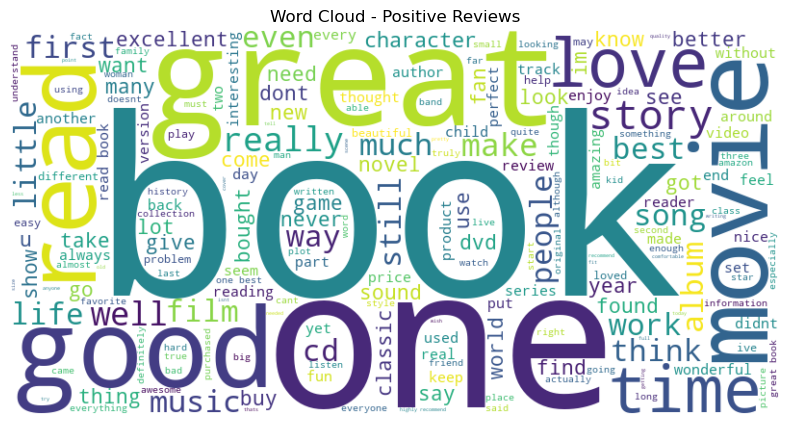

In [15]:
positive_text = " ".join(df[df['label'] == 'pos']['clean_review'])


wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

# Display
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud - Positive Reviews")
plt.show()

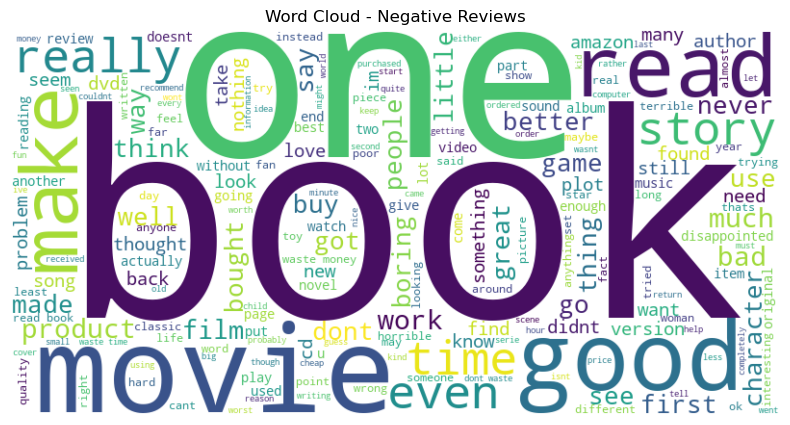

In [16]:

negative_text = " ".join(df[df['label'] == 'neg']['clean_review'])

# Generate Word Cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_text)

# Display
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud - Negative Reviews")
plt.show()

      Word  Frequency
0     book       3861
1    great       2089
2      one       1936
3     good       1638
4     read       1574
5     like       1320
6    movie       1295
7     time       1135
8     love       1036
9    would        943
10     get        936
11    well        857
12   story        857
13  really        827
14    best        801
15   first        708
16    make        705
17    work        679
18    year        677
19    much        650


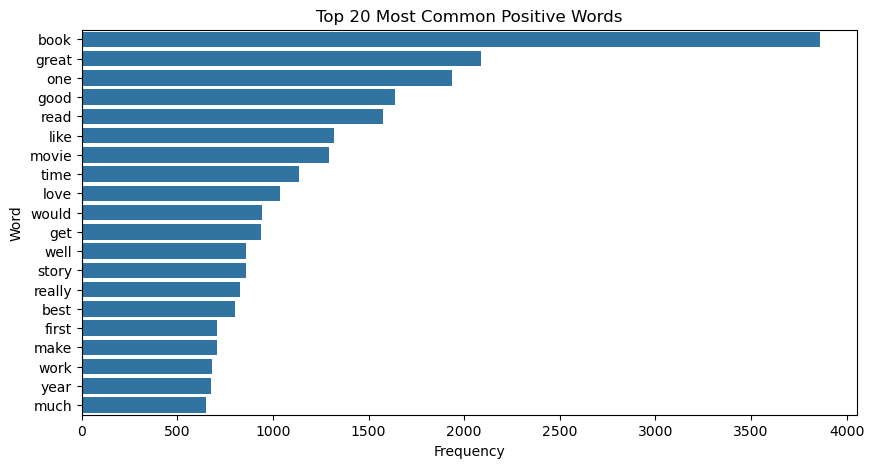

In [17]:
from collections import Counter


positive_words = " ".join(df[df['label'] == 'pos']['clean_review']).split()


positive_counts = Counter(positive_words)


top_positive = pd.DataFrame(
    positive_counts.most_common(20),
    columns=['Word', 'Frequency']
)


print(top_positive)


plt.figure(figsize=(10,5))
sns.barplot(data=top_positive, x='Frequency', y='Word')
plt.title("Top 20 Most Common Positive Words")
plt.show()

      Word  Frequency
0     book       3683
1      one       2119
2    movie       1732
3     like       1570
4    would       1438
5      get       1285
6     time       1274
7     dont       1240
8     read       1238
9     good       1137
10    even        898
11     buy        821
12  really        778
13    much        769
14    make        761
15    work        761
16   story        755
17     bad        749
18   money        746
19   first        736


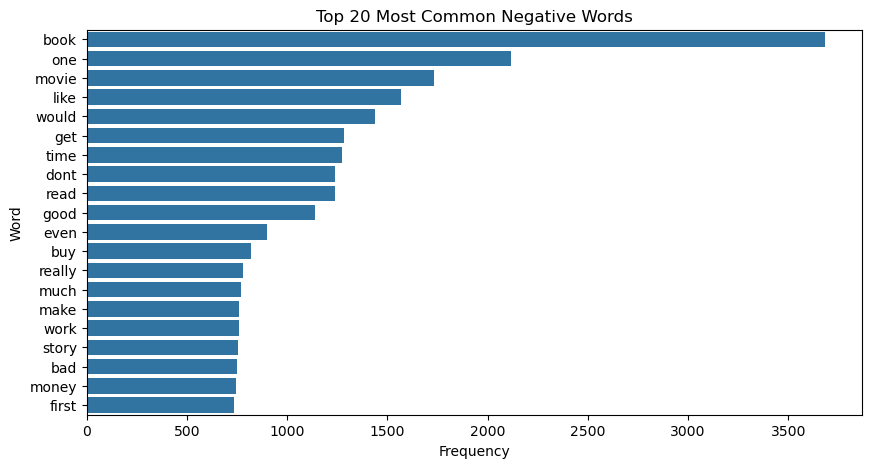

In [18]:
from collections import Counter

negative_words = " ".join(df[df['label'] == 'neg']['clean_review']).split()

negative_counts = Counter(negative_words)

top_negative = pd.DataFrame(
    negative_counts.most_common(20),
    columns=['Word', 'Frequency']
)

print(top_negative)

plt.figure(figsize=(10,5))
sns.barplot(data=top_negative, x='Frequency', y='Word')
plt.title("Top 20 Most Common Negative Words")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()

In [19]:
print(df['label'].unique())
print(df['label'].value_counts())

['pos' 'neg']
label
neg    5097
pos    4903
Name: count, dtype: int64


In [20]:
# Encode labels
df['label'] = df['label'].map({'pos': 1, 'neg': 0})

# Verify encoding
df[['label', 'clean_review']].head()

,label,clean_review
0,1,stuning even nongamer sound track beautiful pa...
1,1,best soundtrack ever anything im reading lot r...
2,1,amazing soundtrack favorite music time hand in...
3,1,excellent soundtrack truly like soundtrack enj...
4,1,remember pull jaw floor hearing youve played g...


## Feature Extraction using TF-IDF
#### Machine learning models cannot understand text directly.
#### TF-IDF converts the review text into numbers so that the models can learn from the data.

In [21]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_review'])
y = df['label']
print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (10000, 5000)
Target Shape: (10000,)


In [22]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (8000, 5000)
X_test : (2000, 5000)
y_train: (8000,)
y_test : (2000,)


## LOGISTIC MODEL

## Model Training

#### In this step, machine learning models are trained using the processed review data.
#### The models used are:
#### Logistic Regression
#### Support Vector Machine (SVM)

T

In [23]:
# Create the Logistic Regression model
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


Accuracy: 0.849

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1019
           1       0.85      0.84      0.85       981

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



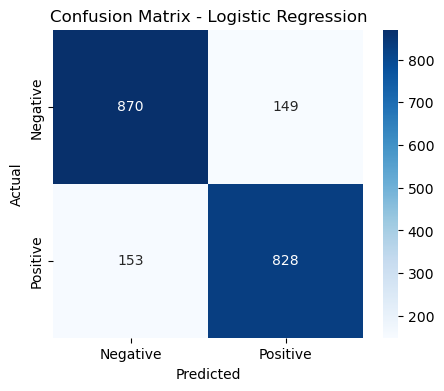

In [24]:
y_pred = lr_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### SVM model

In [25]:
svm_model = LinearSVC(random_state=42)
svm_model.fit(X_train, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,42


Accuracy: 0.832

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.83      0.83      1019
           1       0.82      0.84      0.83       981

    accuracy                           0.83      2000
   macro avg       0.83      0.83      0.83      2000
weighted avg       0.83      0.83      0.83      2000



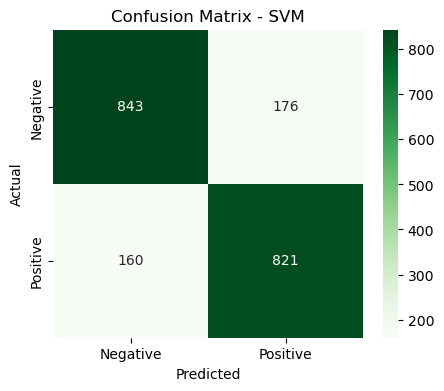

In [26]:
y_pred_svm = svm_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [27]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(
    LogisticRegression(random_state=42),
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:", cv_scores)
print("Mean Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Cross Validation Scores: [0.85   0.826  0.8165 0.8255 0.8465]
Mean Accuracy: 0.8328999999999999
Standard Deviation: 0.013028430450365083


In [28]:
!pip install transformers torch -q


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
from transformers import pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [30]:

bert_model = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

print("BERT model loaded successfully!")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

BERT model loaded successfully!


In [ ]:

bert_predictions = []

for review in df['review']:
    result = bert_model(review[:512])[0]  
    if result['label'] == 'POSITIVE':
        bert_predictions.append(1)
    else:
        bert_predictions.append(0)

print("Prediction completed!")

In [ ]:
y_true = df['label']
accuracy = accuracy_score(y_true, bert_predictions)
print("BERT Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_true, bert_predictions))
cm = confusion_matrix(y_true, bert_predictions)
plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)
plt.title("Confusion Matrix - BERT")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
print(type(bert_predictions))
print(len(bert_predictions))

# Discussion and Conclusion

## Discussion
#### The dataset was cleaned by removing duplicate and missing values. The review text was then preprocessed and converted into numerical values using TF-IDF.Logistic Regression and SVM were trained to classify the reviews. Both models gave good accuracy and were able to identify positive and negative reviews correctly. A pre-trained BERT model was also used for sentiment prediction to compare with the machine learning models.The graphs and word clouds helped to understand the review data and the common words used in positive and negative reviews.

## Conclusion
#### This project successfully built a sentiment analysis system for Amazon reviews.The models were able to classify reviews as positive or negative with good performance. Text preprocessing and TF-IDF helped improve the model results. BERT also showed that deep learning models can perform sentiment analysis effectively.

